# Overview

This notebook investigates whether correlated variation among volatile organic compounds (VOCs) across plant varieties reflects shared genetic regulation or arises from non-genetic factors such as environmental variation, batch effects, or preprocessing artifacts.

# Objectives
Identify patterns of co-variation among VOC traits using dimensionality reduction (PCA)
Interpret the biological meaning of major principal components
Construct a trait-by-locus matrix from GWAS results
Evaluate whether phenotypic correlations are supported by shared genetic associations
Data
Phenotypic data: VOC abundance matrix (samples × compounds)
Genotypic data: GWAS summary statistics for each VOC trait

In [0]:
# ======================
# IMPORTS
# ======================
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load Data

In [0]:




CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

with open(CONFIG_PATH, "r") as f:
    CONFIG = yaml.safe_load(f)


GWAS_TABLE = CONFIG["data"]["gwas_table_newharvested"]

TAGLO_TABLE =CONFIG["paths"]["TAGLO_TABLE"]
AROMA_MATRIX_PATH = CONFIG["paths"]["aroma_matrix_newharvested"]
df_pheno = pd.read_csv(AROMA_MATRIX_PATH)



#  PCA Analysis

In [0]:
# ======================
# CONFIG
# ======================
SAVE_DIR = "/Volumes/bmqg/default_bronze/fatemeh/final_project/results/"


# ======================
# SETUP
# ======================
def setup_output_dir(path):
    os.makedirs(path, exist_ok=True)


# ======================
# PREPARE PHENOTYPE MATRIX
# ======================
def prepare_pheno_matrix(df_pheno):
    if "Variety" not in df_pheno.columns:
        raise ValueError("Variety column not found in df_pheno")

    variety_ids = df_pheno["Variety"]
    X = df_pheno.drop(columns=["Variety"])

    # ensure numeric
    X = X.apply(pd.to_numeric, errors="raise")

    print("NaNs in X:", int(X.isna().sum().sum()))

    # impute
    if X.isna().any().any():
        X_imp = SimpleImputer(strategy="median").fit_transform(X.values)
    else:
        X_imp = X.values

    # scale
    X_scaled = StandardScaler().fit_transform(X_imp)

    return X_scaled, variety_ids, X.columns


# ======================
# PCA
# ======================
def run_pca(X, n_features):
    n_comp = min(10, n_features)

    pca = PCA(n_components=n_comp, random_state=0)
    scores = pca.fit_transform(X)

    return pca, scores


# ======================
# BUILD PCA TRAITS (for GWAS)
# ======================
def build_pca_traits(scores, variety_ids, save_dir):
    pca_traits = pd.DataFrame(
        scores[:, :5],
        columns=["PC1", "PC2", "PC3", "PC4", "PC5"]
    )

    pca_traits.insert(0, "Variety", variety_ids.values)
    pca_traits.set_index("Variety", inplace=True)

    out_path = f"{save_dir}/pca_traits_for_gwas.csv"
    pca_traits.to_csv(out_path)

    return pca_traits, out_path


# ======================
# LOADINGS
# ======================
def compute_loadings(pca, feature_names, save_dir):
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    out_path = f"{save_dir}/pca_loadings_all_traits_new.csv"
    loadings.to_csv(out_path)

    return loadings, out_path


# ======================
# SIMILARITY (PCA loading space)
# ======================
def compute_loading_similarity(loadings, save_dir):
    K = min(5, loadings.shape[1])
    L = loadings.iloc[:, :K].copy()

    Ln = L.values / (np.linalg.norm(L.values, axis=1, keepdims=True) + 1e-12)

    sim = pd.DataFrame(Ln @ Ln.T, index=L.index, columns=L.index)

    pairs = (
        sim.where(np.triu(np.ones(sim.shape), 1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={
            "level_0": "trait1",
            "level_1": "trait2",
            0: "cos_sim"
        })
        .sort_values("cos_sim", ascending=False)
    )

    out_path = f"{save_dir}/top_pairs_pca_loading_similarity_new.csv"
    pairs.head(50).to_csv(out_path, index=False)

    return pairs, out_path


# ======================
# PLOT
# ======================
def plot_loadings(loadings, save_dir):
    L2 = loadings[["PC1", "PC2"]].copy()
    L2["r"] = np.sqrt(L2["PC1"]**2 + L2["PC2"]**2)

    topN = min(50, len(L2))
    top = L2.sort_values("r", ascending=False).head(topN)

    plt.figure(figsize=(10, 8))

    plt.scatter(L2["PC1"], L2["PC2"], s=20, alpha=0.8)

    for name, row in top.iterrows():
        plt.annotate(
            name,
            xy=(row["PC1"], row["PC2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    plt.axhline(0, color="gray", linewidth=0.5)
    plt.axvline(0, color="gray", linewidth=0.5)

    plt.title("Trait loadings on PC1 vs PC2 (top contributors)")
    plt.xlabel("PC1 loading")
    plt.ylabel("PC2 loading")

    plt.tight_layout()

    plot_path = f"{save_dir}/pca_trait_loadings_PC1_PC2_labeled_new.png"
    csv_path = f"{save_dir}/top_traits_by_loading_distance_new.csv"

    plt.savefig(plot_path, dpi=250)
    plt.show()

    top.to_csv(csv_path)

    return plot_path, csv_path


# ======================
# MAIN PIPELINE
# ======================
def run_pipeline(df_pheno):
    setup_output_dir(SAVE_DIR)

    # Prepare data
    X, variety_ids, feature_names = prepare_pheno_matrix(df_pheno)

    # PCA
    pca, scores = run_pca(X, X.shape[1])

    # Outputs
    pca_traits, p1 = build_pca_traits(scores, variety_ids, SAVE_DIR)
    loadings, p2 = compute_loadings(pca, feature_names, SAVE_DIR)
    pairs, p3 = compute_loading_similarity(loadings, SAVE_DIR)
    plot_path, p4 = plot_loadings(loadings, SAVE_DIR)

    # Logs
    print("Saved:", p1)
    print("Saved:", p2)
    print("Saved:", p3)
    print("Saved:", plot_path)

NaNs in X: 0


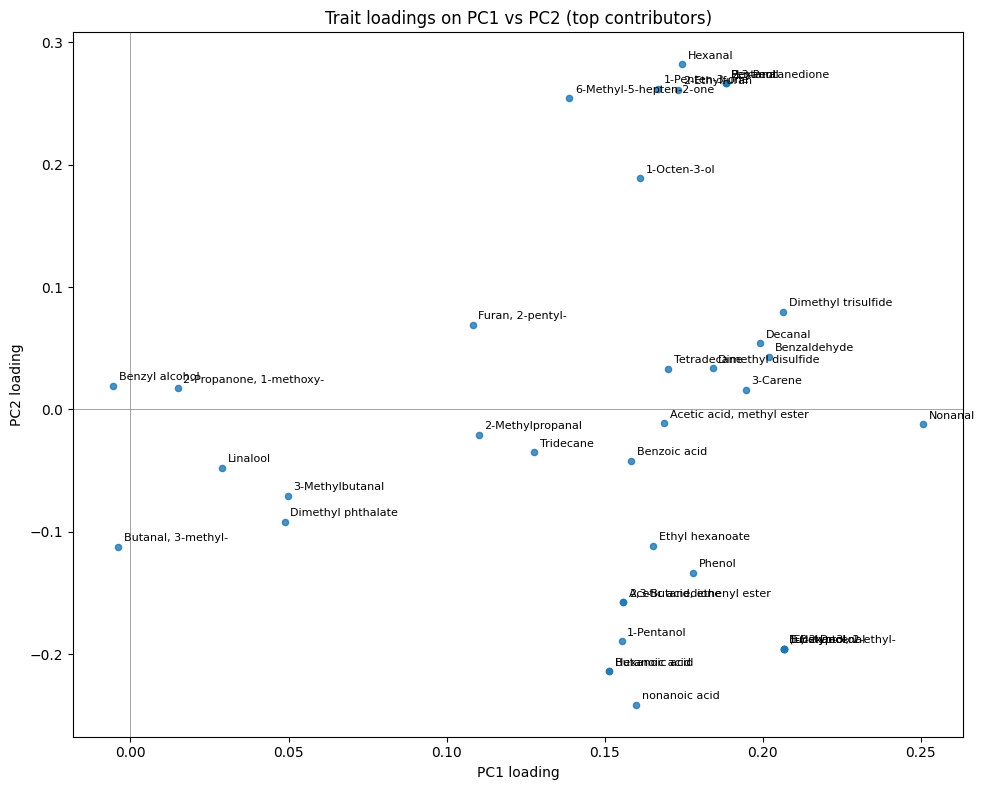

Saved: /Volumes/bmqg/default_bronze/fatemeh/final_project/results//pca_traits_for_gwas.csv
Saved: /Volumes/bmqg/default_bronze/fatemeh/final_project/results//pca_loadings_all_traits_new.csv
Saved: /Volumes/bmqg/default_bronze/fatemeh/final_project/results//top_pairs_pca_loading_similarity_new.csv
Saved: /Volumes/bmqg/default_bronze/fatemeh/final_project/results//pca_trait_loadings_PC1_PC2_labeled_new.png


In [0]:
run_pipeline(df_pheno)

 Top-right region (high PC1 + high PC2)
Examples: Hexanal, 1-Octen-3-ol, 6-Methyl-5-hepten-2-one
Lipid oxidation / green-note compounds
Fresh, grassy, “green” aroma
Likely dominant in fresh potato aroma

 Bottom-right region (high PC1 + low PC2)
Phenol, Ethyl hexanoate, acids
Fatty acids, esters, phenolics
Heavier, sometimes fermented or storage-related notes
✔ May reflect metabolic or early degradation signals


Left side (low PC1)

Examples: Benzyl alcohol, Linalool, 3-Methylbutanal
Minor contributors to overall variation
Possibly background aroma or less variable compounds



 PC1 separates:
 Fresh green volatiles vs heavier/secondary compounds

 PC2 separates:
 Lipid-derived volatiles vs other chemical classes

 Overall conclusion

The dominant variation in new harvested potato aroma is driven by lipid-derived “green” volatiles, while secondary variation reflects acids, esters, and minor aroma compounds.

# Integrative Analysis of Phenotypic Co-variation and GWAS-Derived Genetic Similarity

SAVE_DIR: /Volumes/bmqg/default_bronze/fatemeh/final_project/results/
GWAS matrix shape: (32, 489)
Common traits: 32
Underpowered traits: 15
verdict
GWAS underpowered / inconclusive                      360
Other / unclear                                       128
Likely shared genetics                                  6
Genetic similarity without phenotypic co-variation      1
Likely batch/env/processing                             1
Name: count, dtype: int64


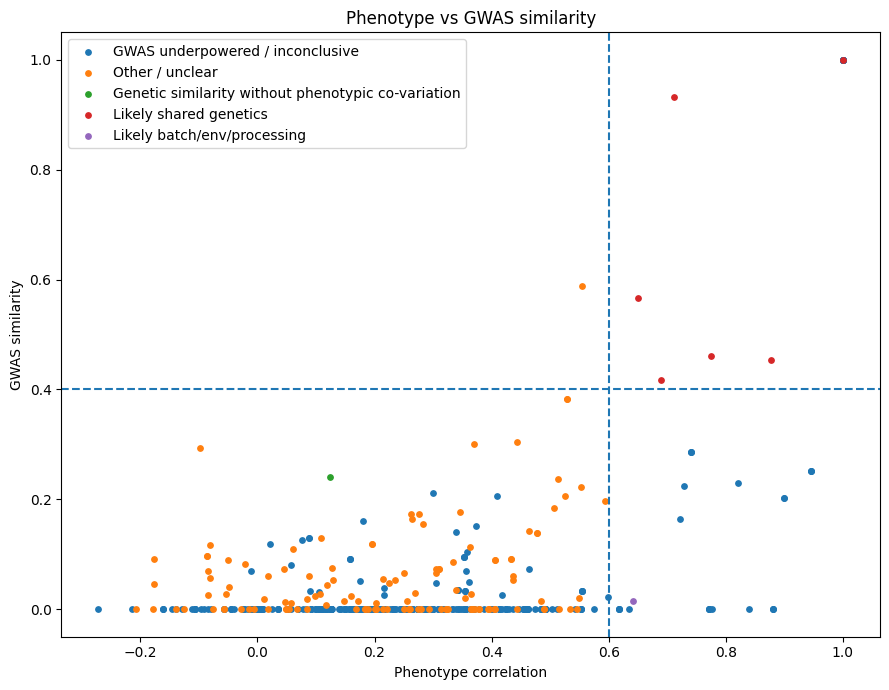

DONE


In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
# ============================================================
# 0) SETUP
# ============================================================

if "SAVE_DIR" not in globals() or SAVE_DIR is None:
    SAVE_DIR = "/tmp"

os.makedirs(SAVE_DIR, exist_ok=True)
print("SAVE_DIR:", SAVE_DIR)

# ---- parameters
window_bp = 500_000
p_keep = 1e-6
TOPK_LOCI_PER_TRAIT = 200
eps = 1e-300

XTH = 0.60   # phenotype threshold
YTH = 0.40   # GWAS similarity threshold


# ============================================================
# 1) BUILD GWAS MATRIX (trait × locus)
# ============================================================

base = (
    spark.table(GWAS_TABLE)
    .select(
        F.col("trait").cast("string"),
        F.col("chrom").cast("string"),
        F.col("start").cast("long"),
        F.col("p_wald").cast("double"),
    )
    .dropna()
    .filter(F.col("start") >= 0)
    .filter(F.col("p_wald") > 0)
    .filter(F.col("p_wald") <= p_keep)
    .withColumn("window", (F.col("start")/window_bp).cast("long") * window_bp)
    .withColumn("locus", F.concat_ws(":", "chrom", "window"))
    .withColumn("p_safe", F.when(F.col("p_wald") < eps, eps).otherwise(F.col("p_wald")))
    .withColumn("nlp", -F.log10("p_safe"))
)

agg = base.groupBy("trait", "locus").agg(F.max("nlp").alias("nlp"))

w = Window.partitionBy("trait").orderBy(F.desc("nlp"))

agg_small = (
    agg.withColumn("rn", F.row_number().over(w))
       .filter(F.col("rn") <= TOPK_LOCI_PER_TRAIT)
       .select("trait", "locus", "nlp")
).toPandas()

M = agg_small.pivot_table(index="trait", columns="locus", values="nlp", fill_value=0.0)

print("GWAS matrix shape:", M.shape)


# ============================================================
# 2) PHENOTYPE PROCESSING
# ============================================================

P = df_pheno.copy()

if "Variety" in P.columns:
    P = P.set_index("Variety")

P = P.apply(pd.to_numeric, errors="coerce")
P = np.log1p(P)
P = P.dropna(axis=1, how="all")
P = P.fillna(P.median())

pheno_corr = P.corr(method="spearman")


# ============================================================
# 3) ALIGN TRAITS
# ============================================================

G = M.copy().apply(pd.to_numeric, errors="coerce").fillna(0.0)

common = sorted(set(pheno_corr.columns).intersection(G.index))

pheno_corr = pheno_corr.loc[common, common]
G = G.loc[common]

print("Common traits:", len(common))


# ============================================================
# 4) GWAS COSINE SIMILARITY
# ============================================================

V = G.values
norms = np.linalg.norm(V, axis=1, keepdims=True)

Vn = np.divide(V, norms, out=np.zeros_like(V), where=(norms > 0))
cos_mat = Vn @ Vn.T

gwas_cos = pd.DataFrame(cos_mat, index=common, columns=common)


# ============================================================
# 5) TOP LOCI SETS + JACCARD
# ============================================================

tmp = agg_small.copy()

top_sets = (
    tmp.sort_values(["trait", "nlp"], ascending=[True, False])
       .groupby("trait")
       .head(TOPK_LOCI_PER_TRAIT)
       .groupby("trait")["locus"]
       .apply(set)
       .to_dict()
)

top_sets = {t: top_sets.get(t, set()) for t in common}

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0


# ============================================================
# 6) GWAS POWER CHECK
# ============================================================

gwas_nonzero = (G > 0).sum(axis=1)
topk_size = pd.Series({t: len(top_sets[t]) for t in common})

underpowered = ((gwas_nonzero < 10) | (topk_size < 10)).to_dict()

print("Underpowered traits:", sum(underpowered.values()))


# ============================================================
# 7) PAIR CLASSIFICATION
# ============================================================

from itertools import combinations

rows = []

for t1, t2 in combinations(common, 2):
    rho = float(pheno_corr.loc[t1, t2])
    cos = float(gwas_cos.loc[t1, t2])
    jac = jaccard(top_sets[t1], top_sets[t2])
    up = underpowered.get(t1, True) or underpowered.get(t2, True)

    if up:
        verdict = "GWAS underpowered / inconclusive"
    elif (rho >= XTH) and (cos >= YTH or jac >= 0.1):
        verdict = "Likely shared genetics"
    elif (rho >= XTH) and (cos < 0.15 and jac < 0.02):
        verdict = "Likely batch/env/processing"
    elif (rho < 0.2) and (cos >= YTH or jac >= 0.1):
        verdict = "Genetic similarity without phenotypic co-variation"
    else:
        verdict = "Other / unclear"

    rows.append([t1, t2, rho, cos, jac, verdict, up])

pairs = pd.DataFrame(rows, columns=[
    "trait1","trait2","pheno_rho","gwas_cos","jaccard","verdict","underpowered"
])

print(pairs["verdict"].value_counts())


# ============================================================
# 8) SAVE RESULTS
# ============================================================

pairs.to_csv(f"{SAVE_DIR}/phenotype_vs_gwas_pair_evidence_new.csv", index=False)

pairs.query("verdict == 'Likely shared genetics'") \
     .to_csv(f"{SAVE_DIR}/pairs_shared_genetics_new.csv", index=False)

pairs.query("verdict == 'Likely batch/env/processing'") \
     .to_csv(f"{SAVE_DIR}/pairs_non_genetic_new.csv", index=False)

pairs.query("verdict == 'GWAS underpowered / inconclusive'") \
     .to_csv(f"{SAVE_DIR}/pairs_underpowered_new.csv", index=False)


# ============================================================
# 9) PLOT
# ============================================================

plt.figure(figsize=(9,7))

for label in pairs["verdict"].unique():
    subset = pairs[pairs["verdict"] == label]
    plt.scatter(subset["pheno_rho"], subset["gwas_cos"], s=15, label=label)

plt.axvline(XTH, linestyle="--")
plt.axhline(YTH, linestyle="--")

plt.xlabel("Phenotype correlation")
plt.ylabel("GWAS similarity")
plt.title("Phenotype vs GWAS similarity")

plt.legend()
plt.tight_layout()

plt.savefig(f"{SAVE_DIR}/phenotype_vs_gwas_new.png", dpi=200)
plt.show()


# ============================================================
# 10) SHARED LOCI (TOP HITS)
# ============================================================

def shared_loci(t1, t2):
    return list(top_sets[t1] & top_sets[t2])

top_pairs = pairs.query("verdict == 'Likely shared genetics'").head(20)

shared = []

for r in top_pairs.itertuples(index=False):
    sl = shared_loci(r.trait1, r.trait2)
    shared.append([r.trait1, r.trait2, len(sl), sl[:20]])

shared_df = pd.DataFrame(shared, columns=["trait1","trait2","n_shared","loci_head"])

shared_df.to_csv(f"{SAVE_DIR}/top_shared_loci.csv_new", index=False)

print("DONE")

In new harvested potatoes, only a limited number of VOC relationships are explained by shared genetics, while most observed co-variation likely arises from non-genetic or weakly powered signals.